# Neipel Heterogeneous SIR Model Example

This example compares the **classical SIR model** with the **Neipel heterogeneous SIR model**. The Neipel model accounts for population heterogeneity in individual susceptibility using a gamma distribution shape parameter `alpha`.

- **Large `alpha`**: Model approaches homogeneous (classical) SIR
- **Small `alpha`**: Strong heterogeneity in susceptibility

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from epimodels.continuous.models import SIR, NeipelHeterogeneousSIR

## Define Parameters

In [2]:
# Population parameters
N = 100000      # Total population
I0 = 10         # Initial infected
R0_init = 0     # Initial recovered
S0 = N - I0 - R0_init  # Initial susceptible

# Epidemiological parameters
beta = 0.30     # Transmission rate
gamma = 0.10    # Recovery rate

# Time range
t0 = 0
tf = 160

# Heterogeneity parameters to test
alphas = [10.0, 1.0, 0.3, 0.1]  # Large to small alpha

## Run Classical SIR Model

In [3]:
# Initialize and run classical SIR
sir = SIR()
sir(
    inits=[S0, I0, R0_init],
    trange=[t0, tf],
    totpop=N,
    params={"beta": beta, "gamma": gamma},
)

# Extract results
t_sir = np.array(sir.traces["time"])
S_sir = np.array(sir.traces["S"])
I_sir = np.array(sir.traces["I"])
R_sir = np.array(sir.traces["R"])

print(f"Classical SIR: R0 = {beta/gamma:.2f}")

Classical SIR: R0 = 3.00


## Run Neipel Heterogeneous SIR Model

The Neipel model uses state variables `[I, tau]`. We reconstruct `S` and `R` using:
- `S(t) = (N - I0) * (1 + tau/alpha)^(-alpha)`
- `R(t) = N - S - I`

In [4]:
def reconstruct_neipel_states(I, tau, N, I0, alpha):
    """Reconstruct S and R from Neipel model outputs."""
    S = (N - I0) * (1 + tau / alpha) ** (-alpha)
    R = N - S - I
    return S, R

# Store results for different alpha values
neipel_results = []

for alpha in alphas:
    # Initialize and run Neipel model
    neipel = NeipelHeterogeneousSIR()
    neipel(
        inits=[I0, 0],  # Initial I and tau
        trange=[t0, tf],
        totpop=N,
        params={"beta": beta, "gamma": gamma, "alpha": alpha, "I0": I0},
    )
    
    # Extract and reconstruct results
    t = np.array(neipel.traces["time"])
    I = np.array(neipel.traces["I"])
    tau = np.array(neipel.traces["tau"])
    S, R = reconstruct_neipel_states(I, tau, N, I0, alpha)
    
    neipel_results.append({"alpha": alpha, "t": t, "S": S, "I": I, "R": R})
    print(f"Neipel alpha={alpha}: Peak I = {np.max(I):.0f}, Final R = {R[-1]:.0f}")

Neipel alpha=10.0: Peak I = 25457, Final R = 91092
Neipel alpha=1.0: Peak I = 17382, Final R = 66425
Neipel alpha=0.3: Peak I = 9089, Final R = 37208
Neipel alpha=0.1: Peak I = 3766, Final R = 16175


## Plot Comparison: Infected

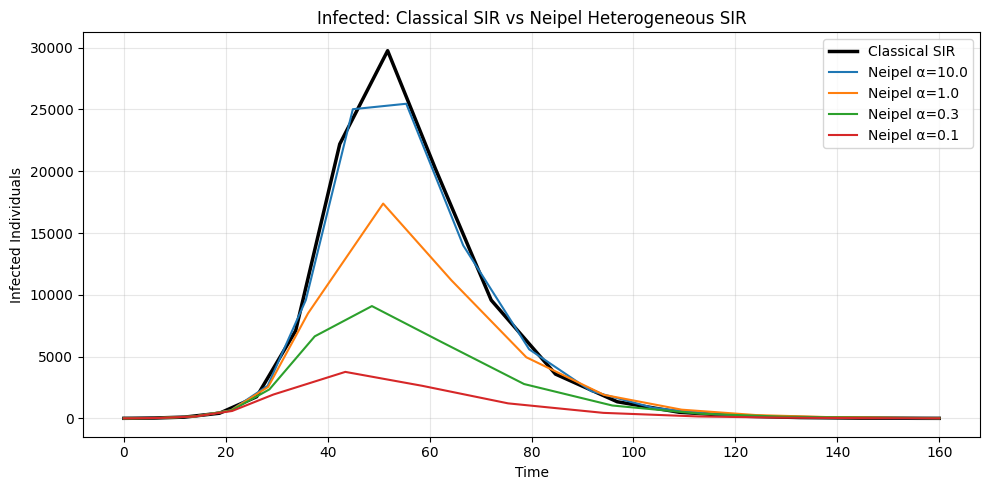

In [5]:
plt.figure(figsize=(10, 5))

# Classical SIR
plt.plot(t_sir, I_sir, label="Classical SIR", linewidth=2.5, color="black")

# Neipel for different alpha values
for res in neipel_results:
    plt.plot(res["t"], res["I"], label=f"Neipel α={res['alpha']}")

plt.xlabel("Time")
plt.ylabel("Infected Individuals")
plt.title("Infected: Classical SIR vs Neipel Heterogeneous SIR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot Comparison: Susceptible

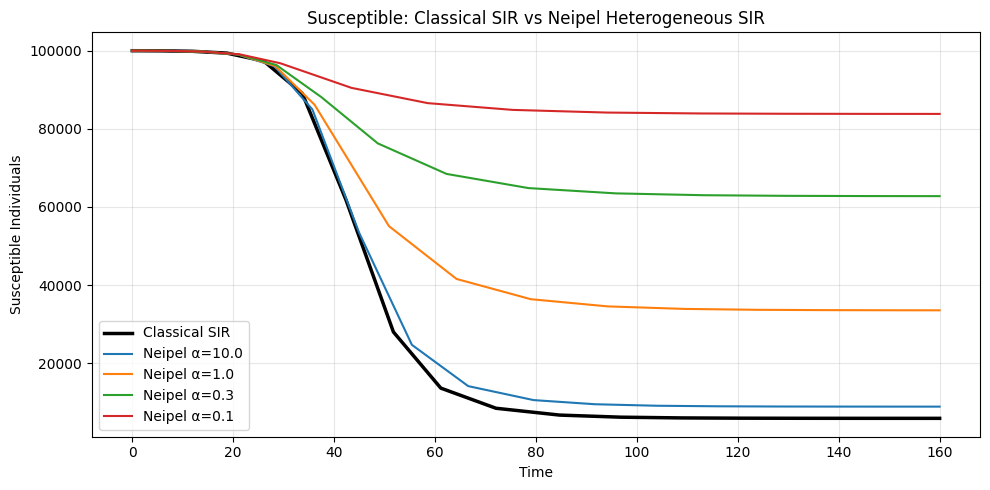

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(t_sir, S_sir, label="Classical SIR", linewidth=2.5, color="black")

for res in neipel_results:
    plt.plot(res["t"], res["S"], label=f"Neipel α={res['alpha']}")

plt.xlabel("Time")
plt.ylabel("Susceptible Individuals")
plt.title("Susceptible: Classical SIR vs Neipel Heterogeneous SIR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot Comparison: Recovered

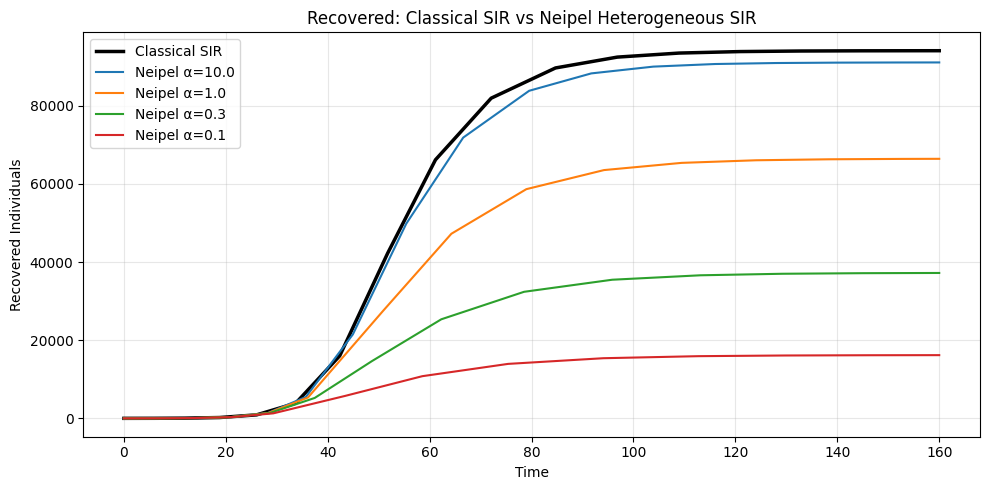

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(t_sir, R_sir, label="Classical SIR", linewidth=2.5, color="black")

for res in neipel_results:
    plt.plot(res["t"], res["R"], label=f"Neipel α={res['alpha']}")

plt.xlabel("Time")
plt.ylabel("Recovered Individuals")
plt.title("Recovered: Classical SIR vs Neipel Heterogeneous SIR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

Key observations:
- **Smaller `alpha`** (more heterogeneity) leads to:
  - Lower epidemic peak
  - Smaller final epidemic size
  - Faster depletion of susceptible population
- **Classical SIR** overestimates both peak infections and final size when population heterogeneity exists